# 🚗 Cityscapes Semantic Segmentation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/cityscapes-segmentation/blob/main/cityscapes_segmentation.ipynb)
![Python](https://img.shields.io/badge/Python-3.10%2B-blue)
![PyTorch](https://img.shields.io/badge/PyTorch-2.x-orange)
![License](https://img.shields.io/badge/License-MIT-green)

End-to-end **semantic segmentation** of urban street scenes using a custom **DeepLabV3+** architecture with a **ResNet-50** backbone, trained on the [Cityscapes dataset](https://www.cityscapes-dataset.com/).

---

## ✨ Features

| Feature | Details |
|---|---|
| **Architecture** | DeepLabV3+ built from scratch (Encoder → ASPP → Decoder) |
| **Backbone** | ResNet-50, pretrained on ImageNet with dilated convolutions |
| **Classes** | 19 Cityscapes categories (road, person, car, sky, …) |
| **Loss** | Combined CE (40%) + Focal (30%) + Dice (30%) |
| **Training** | Mixed-precision (AMP), warmup + cosine LR, differential learning rates |
| **Augmentation** | Crop, flip, color jitter, rain, fog |
| **Demo** | Interactive Gradio app — image & video inference with scene analysis |

---

## 🗂️ Table of Contents

1. [Settings](#cell-1--settings)
2. [Install & Imports](#cell-2--install--imports)
3. [Mount Drive & Download Dataset](#cell-3--mount-drive--download-dataset)
4. [Class Labels & Colors](#cell-4--class-labels--colors)
5. [Find Image-Mask Pairs](#cell-5--find-image-mask-pairs)
6. [Dataset & Augmentations](#cell-6--dataset--augmentations)
7. [Visualize Training Samples](#cell-7--visualize-training-samples)
8. [Model: DeepLabV3+](#cell-8--model-deeplabv3-built-from-scratch)
9. [Loss Function](#cell-9--loss-function)
10. [Optimizer & Scheduler](#cell-10--optimizer--scheduler)
11. [Metrics & Checkpoints](#cell-11--metrics--checkpoints)
12. [Training Loop](#cell-12--training-loop)
13. [Training Curves & Per-Class IoU](#cell-13--training-curves--per-class-iou)
14. [Scene Analysis Engine](#cell-14--scene-analysis-engine)
15. [Inference Helper](#cell-15--inference-helper)
16. [Gradio Demo](#cell-16--gradio-interface)
17. [Baseline Comparison](#cell-17--baseline-comparison)

---

## ⚙️ Quick Start

| Setting | Meaning |
|---|---|
| `SKIP_TRAINING = False` | Train from scratch (first run) |
| `SKIP_TRAINING = True` | Skip training, load saved checkpoint |
| `RESUME = True` | Continue training from last checkpoint |

> **Recommended GPU:** NVIDIA T4 or better (available free on Google Colab). One epoch ≈ 3 min on T4 at 512×512.


## Cell 1 — Settings

Adjust these flags before running. Everything else is automatic.


In [1]:
SKIP_TRAINING = False   # Set True after training once
RESUME        = False   # Set True to add more epochs later
NUM_EPOCHS    = 10       # Start small — increase later with RESUME=True
BATCH_SIZE    = 4       # Reduce to 2 if you get memory errors
IMG_H, IMG_W  = 512, 512
BACKBONE      = 'ResNet-50'

DRIVE_DIR    = '/content/drive/MyDrive/cityscapes_seg'
BEST_CKPT    = f'{DRIVE_DIR}/best_model.pth'
LAST_CKPT    = f'{DRIVE_DIR}/last_model.pth'
HISTORY_FILE = f'{DRIVE_DIR}/history.json'

mode = 'INFERENCE ONLY' if SKIP_TRAINING else ('RESUME' if RESUME else 'TRAIN FROM SCRATCH')
print(f'Mode    : {mode}')
print(f'Backbone: {BACKBONE}  |  Size: {IMG_H}x{IMG_W}  |  Epochs: {NUM_EPOCHS}')

Mode    : INFERENCE ONLY
Backbone: ResNet-50  |  Size: 512x512  |  Epochs: 10


## Cell 2 — Install & Imports

In [2]:
!pip install -q kagglehub segmentation-models-pytorch albumentations gradio scipy

import os, json, random, time, math, tempfile
from pathlib import Path
from scipy import ndimage

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import gradio as gr

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.3 MB/s eta 0:00:00
Device: cuda
GPU  : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM : 102.0 GB


## Cell 3 — Mount Drive & Download Dataset

- Mounts **Google Drive** so checkpoints survive Colab restarts.
- Downloads the [Cityscapes dataset via KaggleHub](https://www.kaggle.com/datasets/electraawais/cityscape-dataset) (~11 GB).
  You need a free Kaggle account and API token — see the [Kaggle docs](https://www.kaggle.com/docs/api).


In [3]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive folder: {DRIVE_DIR}')
for lbl, p in [('Best model', BEST_CKPT), ('Last model', LAST_CKPT)]:
    print(f'  {lbl}: {"Found ✅" if os.path.exists(p) else "Not found"}')

Mounted at /content/drive
Drive folder: /content/drive/MyDrive/cityscapes_seg
  Best model: Found ✅
  Last model: Found ✅


In [4]:
import kagglehub
DATA_PATH = kagglehub.dataset_download('electraawais/cityscape-dataset')
print(f'Dataset: {DATA_PATH}')

100%|██████████| 11.0G/11.0G [05:01<00:00, 39.3MB/s]

Extracting files...


Dataset: /root/.cache/kagglehub/datasets/electraawais/cityscape-dataset/versions/2


## Cell 4 — Class Labels & Colors
Cityscapes has **19 classes**. Each class gets a unique color for visualization.

In [5]:
CITYSCAPES_CLASSES = [
    (0,  'road',          (128,  64, 128)),
    (1,  'sidewalk',      (244,  35, 232)),
    (2,  'building',      ( 70,  70,  70)),
    (3,  'wall',          (102, 102, 156)),
    (4,  'fence',         (190, 153, 153)),
    (5,  'pole',          (153, 153, 153)),
    (6,  'traffic light', (250, 170,  30)),
    (7,  'traffic sign',  (220, 220,   0)),
    (8,  'vegetation',    (107, 142,  35)),
    (9,  'terrain',       (152, 251, 152)),
    (10, 'sky',           ( 70, 130, 180)),
    (11, 'person',        (220,  20,  60)),
    (12, 'rider',         (255,   0,   0)),
    (13, 'car',           (  0,   0, 142)),
    (14, 'truck',         (  0,   0,  70)),
    (15, 'bus',           (  0,  60, 100)),
    (16, 'train',         (  0,  80, 100)),
    (17, 'motorcycle',    (  0,   0, 230)),
    (18, 'bicycle',       (119,  11,  32)),
]

NUM_CLASSES  = len(CITYSCAPES_CLASSES)   # 19
IGNORE_INDEX = 255

PALETTE     = np.zeros((256, 3), dtype=np.uint8)
for cid, _, rgb in CITYSCAPES_CLASSES:
    PALETTE[cid] = rgb

COLOR_ARRAY = np.array([c[2] for c in CITYSCAPES_CLASSES], dtype=np.float32)
ID2NAME     = {c[0]: c[1] for c in CITYSCAPES_CLASSES}
NAME2ID     = {c[1]: c[0] for c in CITYSCAPES_CLASSES}

def rgb_mask_to_label(mask_rgb):
    """Convert color PNG mask → integer class-ID mask."""
    flat  = mask_rgb.reshape(-1, 3).astype(np.float32)
    dists = np.linalg.norm(flat[:, None] - COLOR_ARRAY[None], axis=2)
    return dists.argmin(axis=1).astype(np.uint8).reshape(mask_rgb.shape[:2])

def decode_label_to_rgb(label_map):
    """Convert integer class-ID mask → color RGB image."""
    return PALETTE[label_map.clip(0, 255)]

print(f'✅ {NUM_CLASSES} classes defined.')

✅ 19 classes defined.


## Cell 5 — Find Image-Mask Pairs

In [6]:
IMG_ROOT  = Path(DATA_PATH) / 'Cityscape Dataset' / 'leftImg8bit'
MASK_ROOT = Path(DATA_PATH) / 'Fine Annotations'  / 'gtFine'

train_imgs  = sorted(IMG_ROOT.joinpath('train').rglob('*_leftImg8bit.png'))
train_masks = sorted(MASK_ROOT.joinpath('train').rglob('*_gtFine_color.png'))
val_imgs    = sorted(IMG_ROOT.joinpath('val').rglob('*_leftImg8bit.png'))
val_masks   = sorted(MASK_ROOT.joinpath('val').rglob('*_gtFine_color.png'))

assert len(train_imgs) > 0,              'No train images found!'
assert len(train_imgs) == len(train_masks)
assert len(val_imgs)   == len(val_masks)

print(f'Train: {len(train_imgs)} pairs')
print(f'Val  : {len(val_imgs)} pairs')

Train: 2975 pairs
Val  : 500 pairs


## Cell 6 — Dataset & Augmentations

The `CityscapesDataset` class loads `(image, mask)` pairs. Color PNG masks are converted to integer class-ID tensors.

**Training augmentations** help the model generalise to different conditions:

| Augmentation | Effect |
|---|---|
| `RandomResizedCrop` | Simulates different distances / zoom levels |
| `HorizontalFlip` | Mirrors the scene left-right |
| `ColorJitter` | Varies brightness, contrast, saturation and hue |
| `GaussianBlur` | Simulates camera motion / focus blur |
| `RandomRain` | Synthetic rain streaks |
| `RandomFog` | Simulated fog layer |


In [7]:
class CityscapesDataset(Dataset):
    """
    Loads (image, mask) pairs.
    The mask is a color PNG — we convert it to integer class IDs.
    """
    def __init__(self, img_paths, mask_paths, transform=None):
        self.images    = list(img_paths)
        self.masks     = list(mask_paths)
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img      = cv2.cvtColor(cv2.imread(str(self.images[idx])), cv2.COLOR_BGR2RGB)
        mask_rgb = cv2.cvtColor(cv2.imread(str(self.masks[idx])),  cv2.COLOR_BGR2RGB)
        mask     = rgb_mask_to_label(mask_rgb)   # (H,W) values 0-18
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']
        return img, mask.long()


MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_H, IMG_W), scale=(0.5, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.7),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.RandomRain(p=0.1),
    A.RandomFog(p=0.1),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

train_ds = CityscapesDataset(train_imgs, train_masks, train_transform)
val_ds   = CityscapesDataset(val_imgs,   val_masks,   val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} images → {len(train_loader)} batches')
print(f'Val  : {len(val_ds)} images → {len(val_loader)} batches')
print(f'\nEstimated time per epoch on T4: ~{len(train_loader)*3//60} min')

Train: 2975 images → 743 batches
Val  : 500 images → 125 batches

Estimated time per epoch on T4: ~37 min


## Cell 7 — Visualize Training Samples

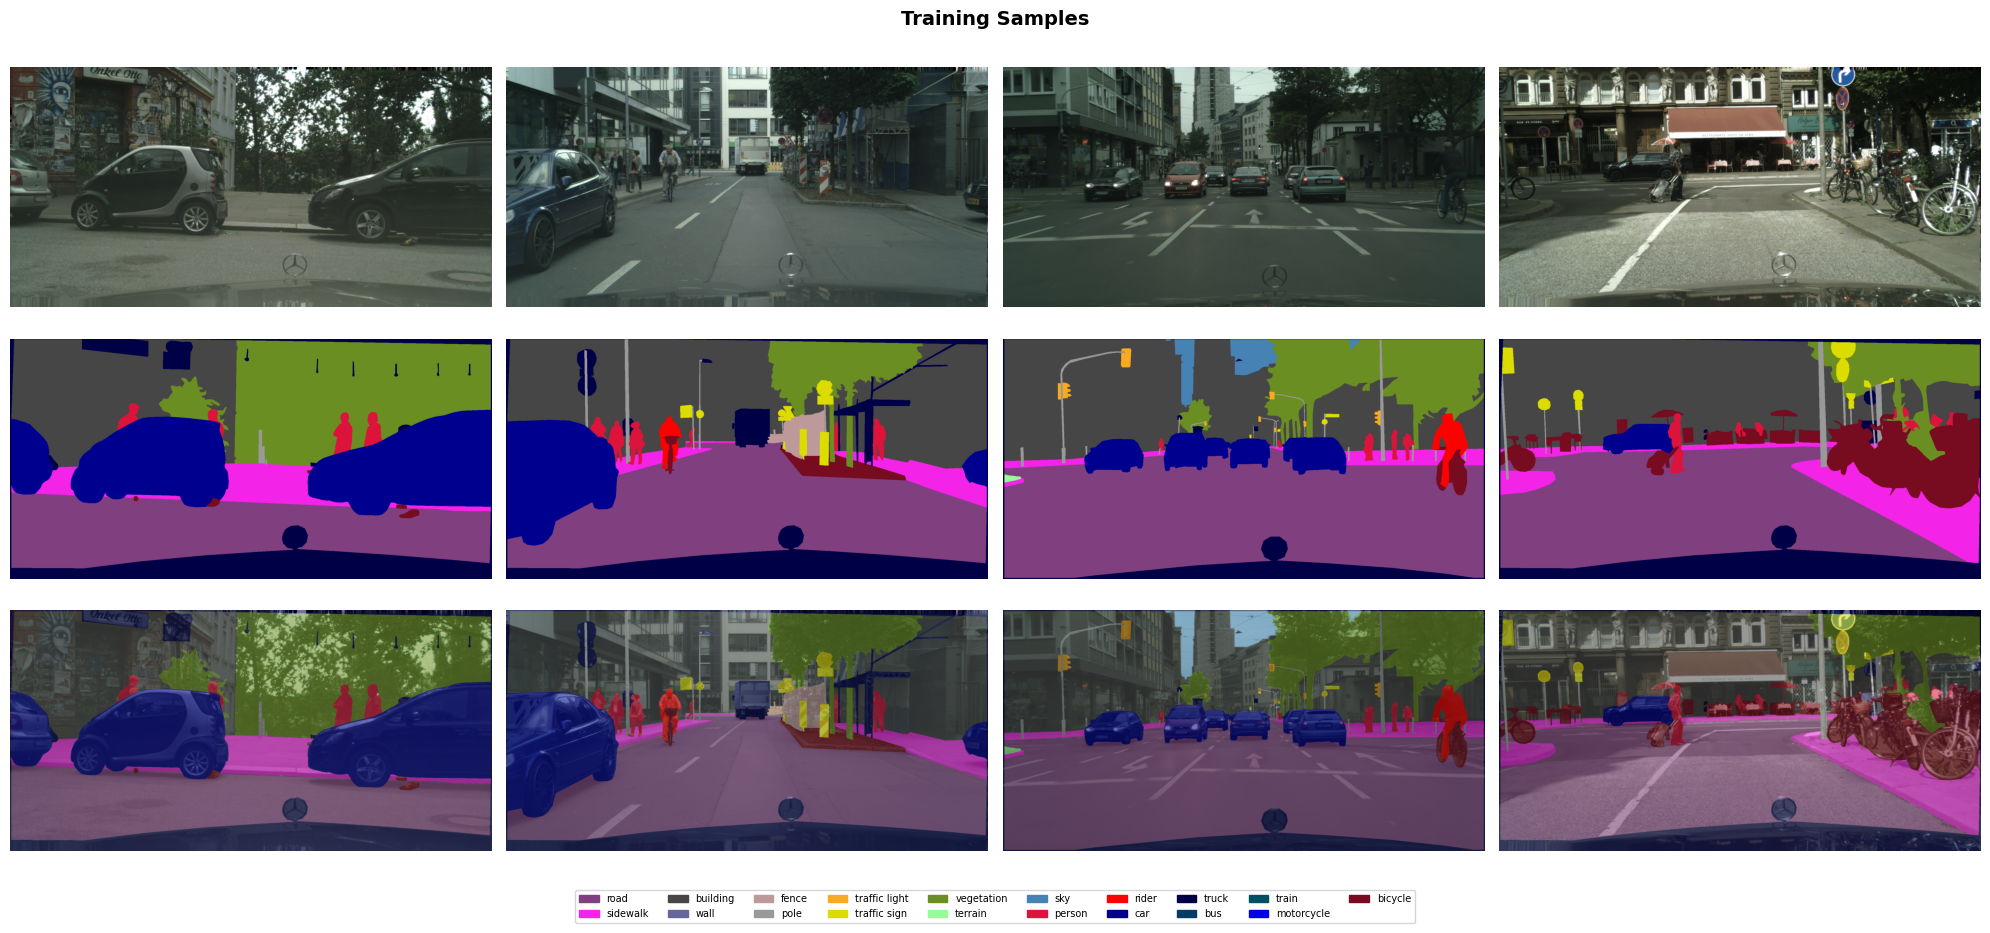

In [8]:
idxs = random.sample(range(len(train_imgs)), 4)
fig, axes = plt.subplots(3, 4, figsize=(20, 9))
fig.suptitle('Training Samples', fontsize=14, fontweight='bold')
for col, idx in enumerate(idxs):
    img      = cv2.cvtColor(cv2.imread(str(train_imgs[idx])),  cv2.COLOR_BGR2RGB)
    mask_rgb = cv2.cvtColor(cv2.imread(str(train_masks[idx])), cv2.COLOR_BGR2RGB)
    label    = rgb_mask_to_label(mask_rgb)
    decoded  = decode_label_to_rgb(label)
    overlay  = (img * 0.45 + decoded * 0.55).astype(np.uint8)
    for row, (data, title) in enumerate([(img,'Image'),(decoded,'GT Mask'),(overlay,'Overlay')]):
        axes[row, col].imshow(data); axes[row, col].axis('off')
        if col == 0: axes[row, col].set_ylabel(title, fontsize=11)
patches = [mpatches.Patch(color=np.array(c[2])/255, label=c[1]) for c in CITYSCAPES_CLASSES]
fig.legend(handles=patches, loc='lower center', ncol=10, fontsize=7, bbox_to_anchor=(0.5,-0.04))
plt.tight_layout(); plt.show()

## Cell 8 — Model: DeepLabV3+ Built from Scratch

The model is assembled from **three distinct building blocks**:

```
Input Image  (B, 3, 512, 512)
      │
      ▼
┌─────────────────────────────────────────────┐
│  PART 1 — ResNetEncoder                     │
│  ResNet-50 (ImageNet pretrained)            │
│  Outputs:                                   │
│    low_level  → (B,  256, H/4, W/4)         │
│    high_level → (B, 2048, H/8, W/8)         │
└──────────────┬──────────────────────────────┘
               │ high_level
               ▼
┌─────────────────────────────────────────────┐
│  PART 2 — ASPP                              │
│  5 parallel branches (1×1, d=6,12,18, GAP)  │
│  Output: (B, 256, H/8, W/8)                 │
└──────────────┬──────────────────────────────┘
               │
               ▼
┌─────────────────────────────────────────────┐
│  PART 3 — Decoder                           │
│  Fuses ASPP + low_level, upsamples 4×       │
│  Output: (B, 19, H, W)                      │
└──────────────┬──────────────────────────────┘
               │
               ▼
Output Mask  (B, 512, 512)  — one class ID per pixel
```

Each class is defined with **dilated convolutions** (no stride in layers 3–4), keeping spatial resolution while expanding the receptive field.


In [9]:
import torchvision.models as tv_models

# ══════════════════════════════════════════════════════════════
#  PART 1 — ResNet-50 Encoder
# ══════════════════════════════════════════════════════════════
class ResNetEncoder(nn.Module):
    """
    Uses ResNet-50 pretrained on ImageNet as a feature extractor.

    We remove the last two layers (avgpool + fc) because we don't
    want classification — we want spatial feature maps.

    We also apply 'dilated convolutions' in layer3 and layer4:
    instead of stride=2 (which shrinks the feature map), we use
    dilation=2/4 to keep the resolution while expanding the
    receptive field. This is a key trick in DeepLabV3+.

    Returns two outputs:
      - low_level  : shallow features from layer1  (B, 256,  H/4, W/4)
      - high_level : deep features from layer4     (B, 2048, H/8, W/8)
    """
    def __init__(self, pretrained=True):
        super().__init__()

        # Load ResNet-50 with ImageNet weights
        resnet = tv_models.resnet50(
            weights=tv_models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        )

        # ── Stem (input → first feature map) ──────────────────
        # conv1: 7×7 conv, stride=2  →  image goes from H to H/2
        # bn1 + relu: normalisation and activation
        # maxpool: stride=2          →  H/2 to H/4
        self.stem = nn.Sequential(
            resnet.conv1,   # (B, 3, H, W)    → (B, 64, H/2, W/2)
            resnet.bn1,
            resnet.relu,
            resnet.maxpool  # (B, 64, H/2, W/2) → (B, 64, H/4, W/4)
        )

        # ── Residual blocks ────────────────────────────────────
        # layer1: keeps H/4 resolution, expands channels to 256
        self.layer1 = resnet.layer1   # (B, 64, H/4, W/4) → (B, 256, H/4, W/4)

        # layer2: stride=2 → shrinks to H/8
        self.layer2 = resnet.layer2   # → (B, 512, H/8, W/8)

        # layer3: we REMOVE stride=2 and ADD dilation=2
        # → keeps H/8 resolution but sees a wider context
        resnet.layer3[0].conv2.stride      = (1, 1)
        resnet.layer3[0].downsample[0].stride = (1, 1)
        for block in resnet.layer3:
            if hasattr(block, 'conv2'):
                block.conv2.dilation = (2, 2)
                block.conv2.padding  = (2, 2)
        self.layer3 = resnet.layer3   # → (B, 1024, H/8, W/8)

        # layer4: REMOVE stride=2 and ADD dilation=4
        # → still H/8, but now the receptive field is very large
        resnet.layer4[0].conv2.stride      = (1, 1)
        resnet.layer4[0].downsample[0].stride = (1, 1)
        for block in resnet.layer4:
            if hasattr(block, 'conv2'):
                block.conv2.dilation = (4, 4)
                block.conv2.padding  = (4, 4)
        self.layer4 = resnet.layer4   # → (B, 2048, H/8, W/8)

    def forward(self, x):
        x          = self.stem(x)     # (B, 64,   H/4, W/4)
        low_level  = self.layer1(x)   # (B, 256,  H/4, W/4)  ← saved for decoder
        x          = self.layer2(low_level)
        x          = self.layer3(x)
        high_level = self.layer4(x)   # (B, 2048, H/8, W/8)  ← goes to ASPP
        return low_level, high_level


# ══════════════════════════════════════════════════════════════
#  PART 2 — ASPP (Atrous Spatial Pyramid Pooling)
# ══════════════════════════════════════════════════════════════
class ASPPConv(nn.Module):
    """
    One dilated convolution branch inside ASPP.

    A normal 3×3 conv looks at a 3×3 neighbourhood.
    A dilated conv with dilation=d inserts (d-1) gaps between
    the kernel weights → looks at a larger area without more params.

    dilation=6  → effective receptive field ≈ 13×13
    dilation=12 → effective receptive field ≈ 25×25
    dilation=18 → effective receptive field ≈ 37×37
    """
    def __init__(self, in_ch, out_ch, dilation):
        super().__init__()
        self.block = nn.Sequential(
            # 3×3 conv with dilation, padding=dilation keeps spatial size
            nn.Conv2d(in_ch, out_ch, kernel_size=3,
                      padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch),   # normalise activations
            nn.ReLU(inplace=True),    # non-linearity
        )
    def forward(self, x): return self.block(x)


class ASPPPooling(nn.Module):
    """
    Global Average Pooling branch of ASPP.

    Collapses the entire feature map to 1×1 → captures global context
    (e.g. 'is this an urban scene or a highway?').
    Then bilinearly upsampled back to the original size.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.gap  = nn.AdaptiveAvgPool2d(1)   # (B, C, H, W) → (B, C, 1, 1)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        size = x.shape[2:]              # remember original H, W
        x    = self.gap(x)              # → (B, C, 1, 1)
        x    = self.conv(x)             # → (B, 256, 1, 1)
        # upsample back to match feature map size
        return nn.functional.interpolate(x, size=size,
                                         mode='bilinear', align_corners=True)


class ASPP(nn.Module):
    """
    Atrous Spatial Pyramid Pooling.

    Runs 5 parallel branches on the same input feature map,
    each seeing the scene at a different scale.
    All branches output 256 channels → concatenated → 1280 ch
    → projected back to 256 channels.

    Input:  (B, 2048, H/8, W/8)
    Output: (B, 256,  H/8, W/8)
    """
    def __init__(self, in_ch=2048, out_ch=256):
        super().__init__()

        # Branch 1: 1×1 conv — no spatial context, just channel mixing
        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )

        # Branch 2, 3, 4: dilated 3×3 convs at different scales
        self.b2 = ASPPConv(in_ch, out_ch, dilation=6)   # medium scale
        self.b3 = ASPPConv(in_ch, out_ch, dilation=12)  # large scale
        self.b4 = ASPPConv(in_ch, out_ch, dilation=18)  # very large scale

        # Branch 5: global average pooling — whole-image context
        self.b5 = ASPPPooling(in_ch, out_ch)

        # Project: 5 × 256 = 1280 channels → back to 256
        self.project = nn.Sequential(
            nn.Conv2d(out_ch * 5, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),   # regularisation
        )

    def forward(self, x):
        # Run all 5 branches in parallel on the same input
        out = torch.cat([self.b1(x), self.b2(x),
                         self.b3(x), self.b4(x),
                         self.b5(x)], dim=1)  # → (B, 1280, H/8, W/8)
        return self.project(out)              # → (B, 256,  H/8, W/8)


# ══════════════════════════════════════════════════════════════
#  PART 3 — Decoder
# ══════════════════════════════════════════════════════════════
class Decoder(nn.Module):
    """
    Combines:
      - ASPP output     (B, 256, H/8, W/8)  — deep, semantic
      - low_level feats (B, 256, H/4, W/4)  — shallow, spatial detail

    Steps:
      1. Project low_level from 256 → 48 channels (reduce noise)
      2. Upsample ASPP output 2× to match low_level size (H/4)
      3. Concatenate: 256 + 48 = 304 channels
      4. Two 3×3 convs to fuse the features
      5. Upsample 4× to reach original image size
      6. 1×1 conv → 19 class scores

    Output: (B, num_classes, H, W)
    """
    def __init__(self, num_classes, low_ch=256, aspp_ch=256):
        super().__init__()

        # Step 1: reduce low_level channels 256 → 48
        # (48 is small enough not to overwhelm the deep features)
        self.low_proj = nn.Sequential(
            nn.Conv2d(low_ch, 48, kernel_size=1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )

        # Steps 3+4: fuse 256 (ASPP) + 48 (low) = 304 channels
        self.fuse = nn.Sequential(
            nn.Conv2d(aspp_ch + 48, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )

        # Step 6: final prediction — one score per class per pixel
        self.classifier = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, low_level, aspp_out, input_size):
        # Step 1: project low-level features
        low = self.low_proj(low_level)   # (B, 48, H/4, W/4)

        # Step 2: upsample ASPP output to match low-level size
        aspp_up = nn.functional.interpolate(
            aspp_out, size=low.shape[2:],
            mode='bilinear', align_corners=True
        )                                # (B, 256, H/4, W/4)

        # Step 3: concatenate along channel dimension
        x = torch.cat([aspp_up, low], dim=1)  # (B, 304, H/4, W/4)

        # Step 4: fuse with two conv layers
        x = self.fuse(x)                 # (B, 256, H/4, W/4)

        # Step 5: upsample back to original image resolution
        x = nn.functional.interpolate(
            x, size=input_size,
            mode='bilinear', align_corners=True
        )                                # (B, 256, H, W)

        # Step 6: final 1×1 conv → class scores
        return self.classifier(x)        # (B, 19, H, W)


# ══════════════════════════════════════════════════════════════
#  FULL MODEL — Puts all 3 parts together
# ══════════════════════════════════════════════════════════════
class DeepLabV3Plus(nn.Module):
    """
    DeepLabV3+ built from scratch:
      Encoder (ResNet-50) → ASPP → Decoder → Output
    """
    def __init__(self, num_classes=19, pretrained=True):
        super().__init__()
        self.encoder = ResNetEncoder(pretrained=pretrained)
        self.aspp    = ASPP(in_ch=2048, out_ch=256)
        self.decoder = Decoder(num_classes=num_classes, low_ch=256, aspp_ch=256)

    def forward(self, x):
        input_size = x.shape[2:]                        # H, W
        low_level, high_level = self.encoder(x)         # Part 1
        aspp_out = self.aspp(high_level)                # Part 2
        out      = self.decoder(low_level, aspp_out, input_size)  # Part 3
        return out                                      # (B, 19, H, W)


# ── Build & test ──────────────────────────────────────────────
model = DeepLabV3Plus(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total/1e6:.1f}M')
print(f'Trainable parameters: {trainable/1e6:.1f}M')
print()
print('Model parts:')
print(f'  Encoder (ResNet-50) : {sum(p.numel() for p in model.encoder.parameters())/1e6:.1f}M params')
print(f'  ASPP                : {sum(p.numel() for p in model.aspp.parameters())/1e6:.1f}M params')
print(f'  Decoder             : {sum(p.numel() for p in model.decoder.parameters())/1e6:.1f}M params')

# Forward pass test
model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE)
    out   = model(dummy)
    print(f'\nInput  → {tuple(dummy.shape)}')
    print(f'Output → {tuple(out.shape)}   (batch, 19 classes, H, W)')
del dummy, out
model.train()
print('\n✅ Model built and tested successfully!')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 234MB/s]


Total parameters    : 40.4M
Trainable parameters: 40.4M

Model parts:
  Encoder (ResNet-50) : 23.5M params
  ASPP                : 15.5M params
  Decoder             : 1.3M params

Input  → (1, 3, 512, 512)
Output → (1, 19, 512, 512)   (batch, 19 classes, H, W)

✅ Model built and tested successfully!


## Cell 9 — Loss Function

A combined loss handles class imbalance (rare classes like `bicycle` and `person` cover very few pixels):

| Loss | Weight | Purpose |
|---|---|---|
| **Cross-Entropy** | 40 % | General, stable baseline |
| **Focal Loss** (γ=2) | 30 % | Focuses on hard / rare pixels |
| **Dice Loss** | 30 % | Improves boundary sharpness |


In [10]:
class CombinedLoss(nn.Module):
    def __init__(self, ignore_index=255, ce_w=0.4, focal_w=0.3, dice_w=0.3, gamma=2.0):
        super().__init__()
        self.ignore_index = ignore_index
        self.ce_w = ce_w; self.focal_w = focal_w; self.dice_w = dice_w
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(ignore_index=ignore_index)

    def focal_loss(self, logits, targets):
        ce = nn.functional.cross_entropy(
            logits, targets, ignore_index=self.ignore_index, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

    def dice_loss(self, logits, targets):
        probs  = torch.softmax(logits, dim=1)
        valid  = (targets != self.ignore_index)
        t_safe = targets.clone(); t_safe[~valid] = 0
        oh     = torch.zeros_like(probs).scatter_(1, t_safe.unsqueeze(1), 1)
        inter  = (probs * oh).sum(dim=(2, 3))
        union  = probs.sum(dim=(2, 3)) + oh.sum(dim=(2, 3))
        return 1 - (2 * inter / (union + 1e-6)).mean()

    def forward(self, logits, targets):
        return (self.ce_w    * self.ce(logits, targets)
              + self.focal_w * self.focal_loss(logits, targets)
              + self.dice_w  * self.dice_loss(logits, targets))

criterion = CombinedLoss(ignore_index=IGNORE_INDEX)
print('✅ CombinedLoss: CE×0.4 + Focal×0.3 + Dice×0.3')

✅ CombinedLoss: CE×0.4 + Focal×0.3 + Dice×0.3


## Cell 10 — Optimizer & Scheduler

Two design choices here:

- **Differential learning rates** — the pretrained encoder trains at 10× lower LR than the new ASPP and decoder heads.
- **Warmup + cosine decay** — LR ramps linearly for 3 epochs, then follows a cosine curve to zero, which avoids early instability and prevents a sharp drop at the end.


In [11]:
# Differential LR: encoder (pretrained ResNet-50) gets smaller LR
# encoder params are already trained on ImageNet → we fine-tune slowly
# decoder + ASPP params are new → they learn faster
optimizer = optim.AdamW([
    {'params': model.encoder.parameters(), 'lr': 2e-5},   # pretrained → slow
    {'params': model.aspp.parameters(),    'lr': 2e-4},   # new → faster
    {'params': model.decoder.parameters(), 'lr': 2e-4},   # new → faster
], weight_decay=1e-4)

def warmup_cosine(epoch):
    warmup = 3
    if epoch < warmup: return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(NUM_EPOCHS - warmup, 1)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)
scaler    = GradScaler('cuda')
print('✅ Optimizer: AdamW | Scheduler: Warmup+Cosine | AMP: enabled')


✅ Optimizer: AdamW | Scheduler: Warmup+Cosine | AMP: enabled


## Cell 11 — Metrics & Checkpoints

In [12]:
class SegMetrics:
    """
    Computes mIoU via confusion matrix.
    IoU per class = TP / (TP + FP + FN)
    mIoU = average across all present classes
    """
    def __init__(self, num_classes, ignore_index=255):
        self.C = num_classes; self.ignore_index = ignore_index
        self.conf = np.zeros((num_classes, num_classes), dtype=np.int64)

    def reset(self): self.conf[:] = 0

    def update(self, pred, target):
        pred   = pred.cpu().numpy().flatten()
        target = target.cpu().numpy().flatten()
        valid  = target != self.ignore_index
        pred, target = pred[valid], target[valid]
        np.add.at(self.conf, (target.clip(0, self.C-1), pred.clip(0, self.C-1)), 1)

    def iou_per_class(self):
        with np.errstate(divide='ignore', invalid='ignore'):
            return np.diag(self.conf) / (self.conf.sum(1) + self.conf.sum(0) - np.diag(self.conf))

    def miou(self):
        iou = self.iou_per_class()
        return float(np.nanmean(iou[self.conf.sum(1) > 0]))

    def pixel_acc(self):
        total = self.conf.sum()
        return float(np.diag(self.conf).sum() / total) if total > 0 else 0.0


def save_checkpoint(path, epoch, miou, history):
    torch.save({'epoch': epoch, 'miou': miou,
                'state_dict': model.state_dict(),
                'optimizer':  optimizer.state_dict(),
                'scheduler':  scheduler.state_dict()}, path)
    with open(HISTORY_FILE, 'w') as f:
        json.dump(history, f, indent=2)
    print(f'  💾 Saved → {Path(path).name}  (epoch={epoch+1}, mIoU={miou*100:.2f}%)')


def load_checkpoint(path):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    print(f'✅ Loaded: {Path(path).name}  epoch={ckpt["epoch"]+1}  mIoU={ckpt["miou"]*100:.2f}%')
    return ckpt


print('✅ SegMetrics and checkpoint utilities ready.')

✅ SegMetrics and checkpoint utilities ready.


## Cell 12 — Training Loop

In [13]:
history = {'train_loss': [], 'val_loss': [], 'miou': [], 'pixel_acc': []}
best_miou = 0.0; start_epoch = 0

# ── Load saved model ─────────────────────────────────────────
if SKIP_TRAINING:
    if not os.path.exists(BEST_CKPT):
        raise FileNotFoundError(f'No saved model at {BEST_CKPT}. Set SKIP_TRAINING=False first.')
    load_checkpoint(BEST_CKPT)
    if os.path.exists(HISTORY_FILE):
        with open(HISTORY_FILE) as f: history = json.load(f)

# ── Resume training ───────────────────────────────────────────
elif RESUME and os.path.exists(LAST_CKPT):
    ckpt = load_checkpoint(LAST_CKPT)
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    start_epoch = ckpt['epoch'] + 1; best_miou = ckpt['miou']
    if os.path.exists(HISTORY_FILE):
        with open(HISTORY_FILE) as f: history = json.load(f)
    print(f'Resuming from epoch {start_epoch}')

# ── Train ─────────────────────────────────────────────────────
if not SKIP_TRAINING:
    metrics = SegMetrics(NUM_CLASSES, IGNORE_INDEX)
    print('🚀 Training started...\n')

    for epoch in range(start_epoch, NUM_EPOCHS):
        t0 = time.time()

        # --- Train ---
        model.train()
        train_loss = 0.0
        for batch_idx, (imgs, masks) in enumerate(train_loader):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            with autocast('cuda'):                           # ✅ fixed
                loss = criterion(model(imgs), masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            train_loss += loss.item()

            # Progress bar every 10 batches
            if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(train_loader):
                done = int(30 * (batch_idx + 1) / len(train_loader))
                bar  = '█' * done + '░' * (30 - done)
                elapsed = time.time() - t0
                eta = elapsed / (batch_idx + 1) * (len(train_loader) - batch_idx - 1)
                print(f'\r  Ep {epoch+1}/{NUM_EPOCHS} [{bar}] '
                      f'{batch_idx+1}/{len(train_loader)} '
                      f'loss={loss.item():.4f}  '
                      f'ETA={eta/60:.1f}min', end='', flush=True)

        print()  # newline after progress bar
        scheduler.step()
        avg_train = train_loss / len(train_loader)

        # --- Validate ---
        model.eval()
        val_loss = 0.0; metrics.reset()
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                with autocast('cuda'):                       # ✅ fixed
                    logits = model(imgs)
                    val_loss += criterion(logits, masks).item()
                metrics.update(logits.argmax(1), masks)

        ep_miou  = metrics.miou()
        ep_pxacc = metrics.pixel_acc()
        avg_val  = val_loss / len(val_loader)

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['miou'].append(ep_miou)
        history['pixel_acc'].append(ep_pxacc)

        print(f'Ep {epoch+1:3d}/{NUM_EPOCHS} | '
              f'Train={avg_train:.4f} | Val={avg_val:.4f} | '
              f'mIoU={ep_miou*100:.2f}% | PxAcc={ep_pxacc*100:.1f}% | '
              f'{(time.time()-t0)/60:.1f}min')

        save_checkpoint(LAST_CKPT, epoch, ep_miou, history)
        if ep_miou > best_miou:
            best_miou = ep_miou
            save_checkpoint(BEST_CKPT, epoch, ep_miou, history)
            print(f'  ⭐ New best mIoU = {best_miou*100:.2f}%')

    print(f'\n🏆 Done! Best mIoU: {best_miou*100:.2f}%')

✅ Loaded: best_model.pth  epoch=10  mIoU=56.96%


## Cell 13 — Training Curves & Per-Class IoU

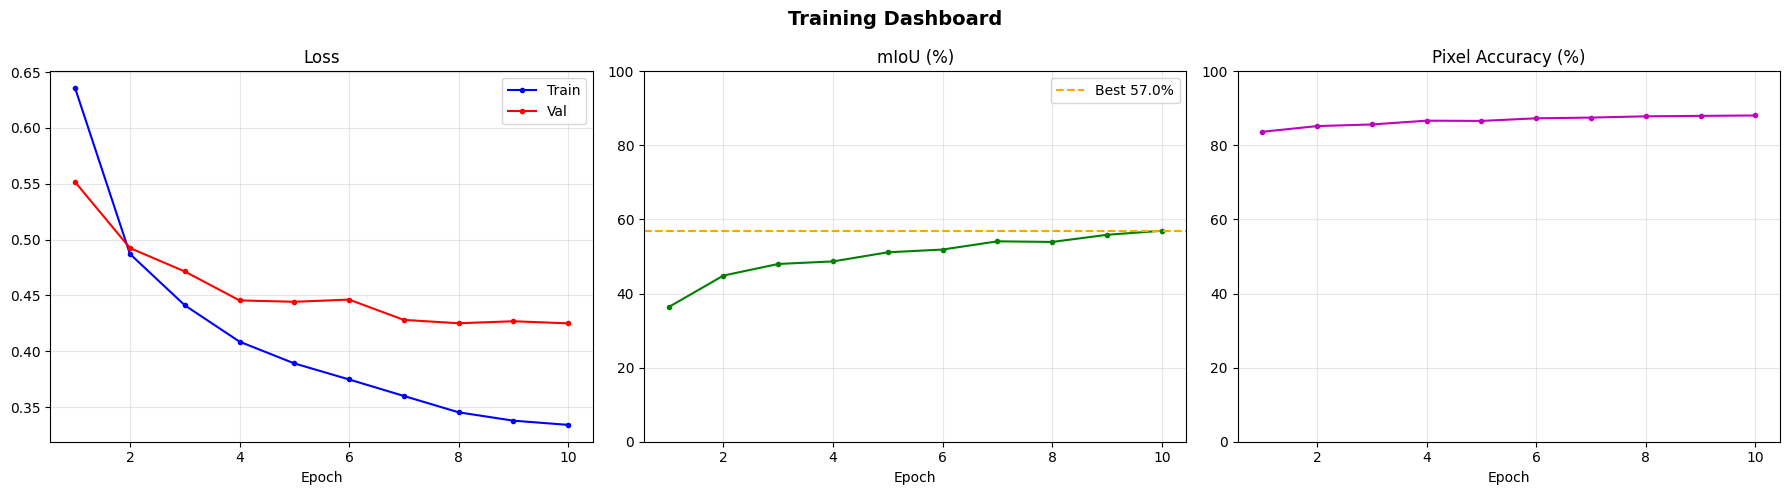

✅ Saved training_curves.png
✅ Loaded: best_model.pth  epoch=10  mIoU=56.96%
Evaluating on validation set...
mIoU: 56.96%  |  Pixel Acc: 88.08%


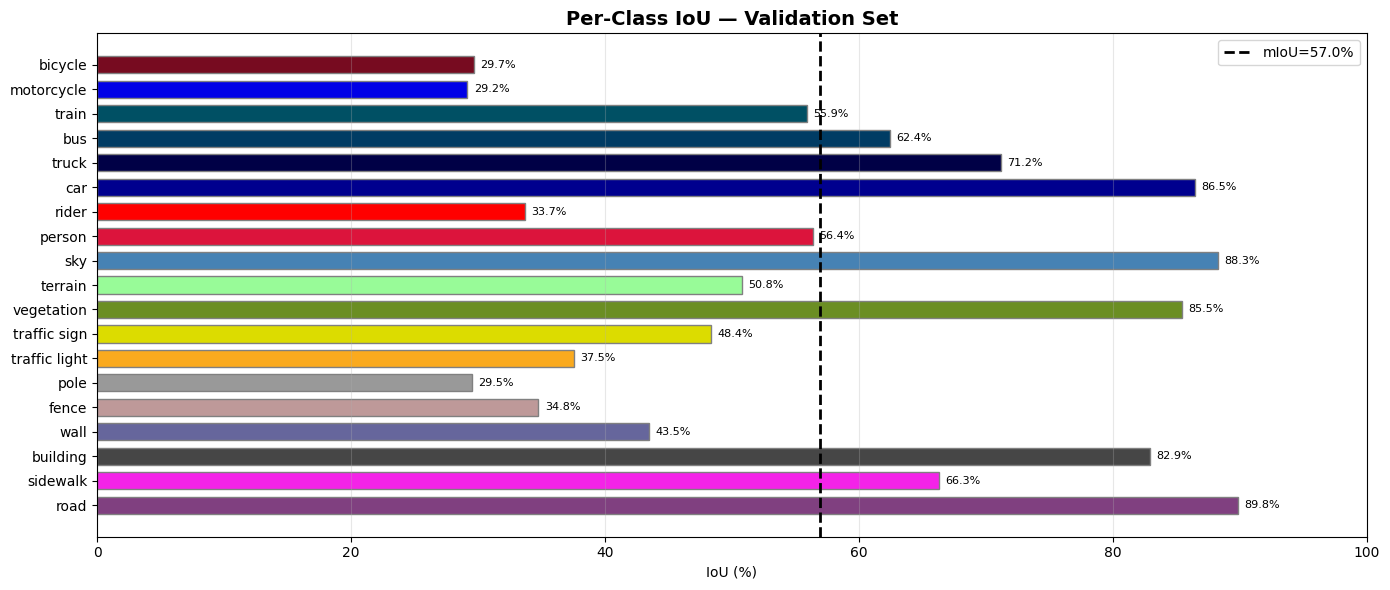

✅ Saved per_class_iou.png


In [14]:
# Training curves
if history['miou']:
    epochs = range(1, len(history['miou']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Training Dashboard', fontsize=14, fontweight='bold')

    axes[0].plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
    axes[0].plot(epochs, history['val_loss'],   'r-o', ms=3, label='Val')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    miou_pct = [m * 100 for m in history['miou']]
    axes[1].plot(epochs, miou_pct, 'g-o', ms=3)
    axes[1].axhline(max(miou_pct), color='orange', ls='--', label=f'Best {max(miou_pct):.1f}%')
    axes[1].set_title('mIoU (%)'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 100); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(epochs, [p * 100 for p in history['pixel_acc']], 'm-o', ms=3)
    axes[2].set_title('Pixel Accuracy (%)'); axes[2].set_xlabel('Epoch')
    axes[2].set_ylim(0, 100); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved training_curves.png')

# Per-class IoU bar chart
load_checkpoint(BEST_CKPT)
model.eval()
m = SegMetrics(NUM_CLASSES, IGNORE_INDEX)
print('Evaluating on validation set...')
with torch.no_grad():
    for imgs, masks in val_loader:
        with autocast('cuda'):
            preds = model(imgs.to(DEVICE)).argmax(1)
        m.update(preds, masks)

iou_vals = m.iou_per_class()
print(f'mIoU: {m.miou()*100:.2f}%  |  Pixel Acc: {m.pixel_acc()*100:.2f}%')

names  = [c[1] for c in CITYSCAPES_CLASSES]
colors = [np.array(c[2])/255 for c in CITYSCAPES_CLASSES]
valid  = m.conf.sum(1) > 0
vals   = [iou_vals[i]*100 if valid[i] and not np.isnan(iou_vals[i]) else 0
          for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(names, vals, color=colors, edgecolor='gray', height=0.7)
ax.axvline(m.miou()*100, color='black', lw=2, ls='--', label=f'mIoU={m.miou()*100:.1f}%')
for bar, v in zip(bars, vals):
    if v > 0: ax.text(v+0.5, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, 100); ax.set_xlabel('IoU (%)')
ax.set_title('Per-Class IoU — Validation Set', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_iou.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved per_class_iou.png')

## Cell 14 — Scene Analysis Engine

After producing a segmentation mask we run a lightweight analysis pass:

- **Connected components** (`scipy.ndimage.label`) counts distinct object blobs, filtered by a minimum pixel size.
- **Congestion level** is derived from total object count: Clear → Light → Moderate → Congested → Very Congested.
- **Driving advice** is generated in plain language from per-class object counts.


In [15]:
PERSON_IDS  = [NAME2ID['person'],  NAME2ID['rider']]
VEHICLE_IDS = [NAME2ID['car'],     NAME2ID['truck'], NAME2ID['bus'], NAME2ID['train']]
BIKE_IDS    = [NAME2ID['bicycle'], NAME2ID['motorcycle']]


def count_objects(pred_mask, class_ids, min_pixels=300):
    """Count distinct connected blobs for given class IDs."""
    counts = {}
    for cid in class_ids:
        binary = (pred_mask == cid).astype(np.uint8)
        if binary.sum() < min_pixels: continue
        labeled, n = ndimage.label(binary)
        real = sum(1 for i in range(1, n+1) if (labeled==i).sum() >= min_pixels)
        if real > 0: counts[ID2NAME[cid]] = real
    return counts


def analyze_scene(pred_mask):
    H, W = pred_mask.shape
    pc = count_objects(pred_mask, PERSON_IDS)
    vc = count_objects(pred_mask, VEHICLE_IDS)
    bc = count_objects(pred_mask, BIKE_IDS)

    n_p = sum(pc.values()); n_v = sum(vc.values()); n_b = sum(bc.values())
    n_total   = n_p + n_v + n_b
    road_frac = ((pred_mask == NAME2ID['road']) |
                 (pred_mask == NAME2ID['sidewalk'])).sum() / (H * W)

    if   n_total == 0:  cong = 'Clear 🟢'
    elif n_total <= 3:  cong = 'Light 🟡'
    elif n_total <= 8:  cong = 'Moderate 🟠'
    elif n_total <= 15: cong = 'Congested 🔴'
    else:               cong = 'Very Congested 🔴🔴'

    advice = []
    if n_p > 0:  advice.append(f'⚠️  {n_p} pedestrian(s) — slow down')
    if n_b > 0:  advice.append(f'🚲 {n_b} cyclist(s) — keep distance')
    if n_v > 6:  advice.append(f'🚗 Heavy traffic ({n_v} vehicles)')
    if road_frac < 0.1: advice.append('🔀 Complex intersection ahead')
    if not advice: advice.append('✅ Road clear — normal conditions')

    return {'n_persons': n_p, 'n_vehicles': n_v, 'n_bikes': n_b,
            'detail': {**pc, **vc, **bc},
            'congestion': cong, 'advice': advice}


def format_report(s):
    lines = ['═'*40, '  SCENE ANALYSIS', '═'*40,
             f'  Congestion  : {s["congestion"]}',
             f'  Pedestrians : {s["n_persons"]}',
             f'  Vehicles    : {s["n_vehicles"]}',
             f'  Cyclists    : {s["n_bikes"]}']
    if s['detail']:
        lines.append('  Objects     :')
        for name, cnt in s['detail'].items():
            lines.append(f'    {name:<16}: {cnt}')
    lines.append('  Advice      :')
    for a in s['advice']: lines.append(f'    {a}')
    lines.append('═'*40)
    return '\n'.join(lines)


print('✅ Scene analysis engine ready.')

✅ Scene analysis engine ready.


## Cell 15 — Inference Helper

In [16]:
@torch.no_grad()
def predict_image(img_np):
    """image (RGB numpy) → overlay, pred_mask, scene dict"""
    model.eval()
    aug    = val_transform(image=img_np, mask=np.zeros(img_np.shape[:2], np.uint8))
    tensor = aug['image'].unsqueeze(0).to(DEVICE)
    with autocast('cuda'):
        logits = model(tensor)
    pred = logits.argmax(1).squeeze(0).cpu().numpy()
    pred_full = cv2.resize(pred.astype(np.uint8),
                           (img_np.shape[1], img_np.shape[0]),
                           interpolation=cv2.INTER_NEAREST)
    seg_rgb = decode_label_to_rgb(pred_full)
    overlay = (img_np * 0.45 + seg_rgb * 0.55).astype(np.uint8)
    scene   = analyze_scene(pred_full)
    return overlay, pred_full, scene


print('✅ predict_image() ready.')

✅ predict_image() ready.


## Cell 16 — Gradio Interface

A two-tab Gradio app (auto-launched with a public `share=True` link):

| Tab | Input | Output |
|---|---|---|
| **📷 Image** | Street photo | Segmentation overlay + scene report |
| **🎬 Video** | Street clip | Processed video with HUD (congestion, object counts) |


In [17]:
# ── Image Tab ────────────────────────────────────────────────
def gradio_image(pil_image):
    if pil_image is None: return None, 'Please upload an image.'
    img_np  = np.array(pil_image.convert('RGB'))
    overlay, _, scene = predict_image(img_np)
    return overlay, format_report(scene)


# ── Video Tab ────────────────────────────────────────────────
def gradio_video(video_path, max_frames_input):
    if video_path is None: return None, 'Please upload a video.'
    max_frames = int(max_frames_input) if max_frames_input else None

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return None, 'Cannot open video.'

    ow  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    oh  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    tot = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    W   = 640; H = int(oh * W / ow)

    out_path = tempfile.mktemp(suffix='_seg.mp4')
    writer   = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (W, H))

    fn = 0; totals = {'p': 0, 'v': 0, 'b': 0}
    while True:
        ret, frame = cap.read()
        if not ret or (max_frames and fn >= max_frames): break

        rgb = cv2.cvtColor(cv2.resize(frame, (W, H)), cv2.COLOR_BGR2RGB)
        overlay, _, scene = predict_image(rgb)

        # HUD overlay
        out_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
        cong    = scene['congestion'].split()[0]
        cv2.rectangle(out_bgr, (5, 5), (290, 65), (0, 0, 0), -1)
        cv2.putText(out_bgr, f'Congestion: {cong}',
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.putText(out_bgr,
                    f'P:{scene["n_persons"]}  V:{scene["n_vehicles"]}  B:{scene["n_bikes"]}',
                    (10, 58), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (180, 220, 255), 2)
        writer.write(out_bgr)

        totals['p'] += scene['n_persons']
        totals['v'] += scene['n_vehicles']
        totals['b'] += scene['n_bikes']
        fn += 1

    cap.release(); writer.release()
    n = max(fn, 1)
    summary = (f'Processed {fn}/{tot} frames\n'
               f'Avg pedestrians/frame : {totals["p"]/n:.1f}\n'
               f'Avg vehicles/frame    : {totals["v"]/n:.1f}\n'
               f'Avg cyclists/frame    : {totals["b"]/n:.1f}')
    return out_path, summary


# ── Build Gradio UI ───────────────────────────────────────────
with gr.Blocks(title='Street Scene Segmentation') as demo:
    gr.Markdown('# 🚗 Street Scene Segmentation')
    gr.Markdown('Upload a street image or video → get segmentation + scene analysis.')

    with gr.Tabs():

        with gr.Tab('📷 Image'):
            with gr.Row():
                with gr.Column():
                    img_in  = gr.Image(label='Upload Street Image', type='pil')
                    img_btn = gr.Button('Analyze', variant='primary')
                with gr.Column():
                    img_out = gr.Image(label='Segmentation Overlay')
                    img_rep = gr.Textbox(label='Scene Report', lines=14)
            img_btn.click(gradio_image, inputs=img_in, outputs=[img_out, img_rep])

        with gr.Tab('🎬 Video'):
            with gr.Row():
                with gr.Column():
                    vid_in  = gr.Video(label='Upload Street Video')
                    vid_fr  = gr.Number(value=120, label='Max frames (keep low for speed)')
                    vid_btn = gr.Button('Process Video', variant='primary')
                with gr.Column():
                    vid_out = gr.Video(label='Output Video')
                    vid_sum = gr.Textbox(label='Summary', lines=6)
            vid_btn.click(gradio_video, inputs=[vid_in, vid_fr], outputs=[vid_out, vid_sum])

demo.launch(share=True)
print('✅ Gradio launched!')

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://066b2279e7022fcaa6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Gradio launched!


## Cell 17 — Baseline Comparison

Compares your trained DeepLabV3+ against common baselines **on the same validation split**.

Baselines evaluated:
- **FCN** (ResNet-50 encoder, random head)
- **PSPNet** (ResNet-50 via `segmentation-models-pytorch`)
- **DeepLabV3** without the decoder (torchvision)
- **FPN** (ResNet-50 via `segmentation-models-pytorch`)

Published paper numbers are also shown for reference. Run this cell **after** Cell 11 (dataset is loaded) and after training.


  BASELINE EVALUATION  (val split, 19 classes)

→ FCN (ResNet-50 encoder)
   ⚠️  Skipped — Invalid Weight class provided; expected ResNet50_Weights but received FCN_ResNet50_Weights.

→ PSPNet (ResNet-50)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

  Eval PSPNet (ResNet-50):   0%|          | 0/125 [00:00<?, ?it/s]

...

   mIoU = 0.84%   Pixel Acc = 6.87%

→ FPN (ResNet-50)


  Eval FPN (ResNet-50):   0%|          | 0/125 [00:10<?, ?it/s]

   mIoU = 2.06%   Pixel Acc = 23.66%

→ YOUR DeepLabV3+ (ResNet-50, trained)


  Eval Your model:   0%|          | 0/125 [00:00<?, ?it/s]

   mIoU = 56.96%   Pixel Acc = 88.08%

  Model                                     mIoU    PxAcc
  — Published paper results (reference) —
    FCN-8s (VGG-16)                        65.3%    91.2%
    SegNet (VGG-16)                        56.1%    90.4%
    ENet                                   58.3%    91.8%
    PSPNet (ResNet-50)                     76.9%    95.1%
    DeepLabV3 (ResNet-50)                  75.7%    94.7%
  ★ DeepLabV3+ (ResNet-50) paper           78.8%    95.4%
  ★ DeepLabV3+ (ResNet-101) paper          82.1%    96.4%
  — Evaluated on YOUR val split —
    PSPNet (ResNet-50)                     0.82%    4.48%
    DeepLabV3 (ResNet-50)                  0.84%    6.87%
    FPN (ResNet-50)                        2.06%   23.66%
  ▶ YOUR DeepLabV3+ (trained)             56.96%   88.08%


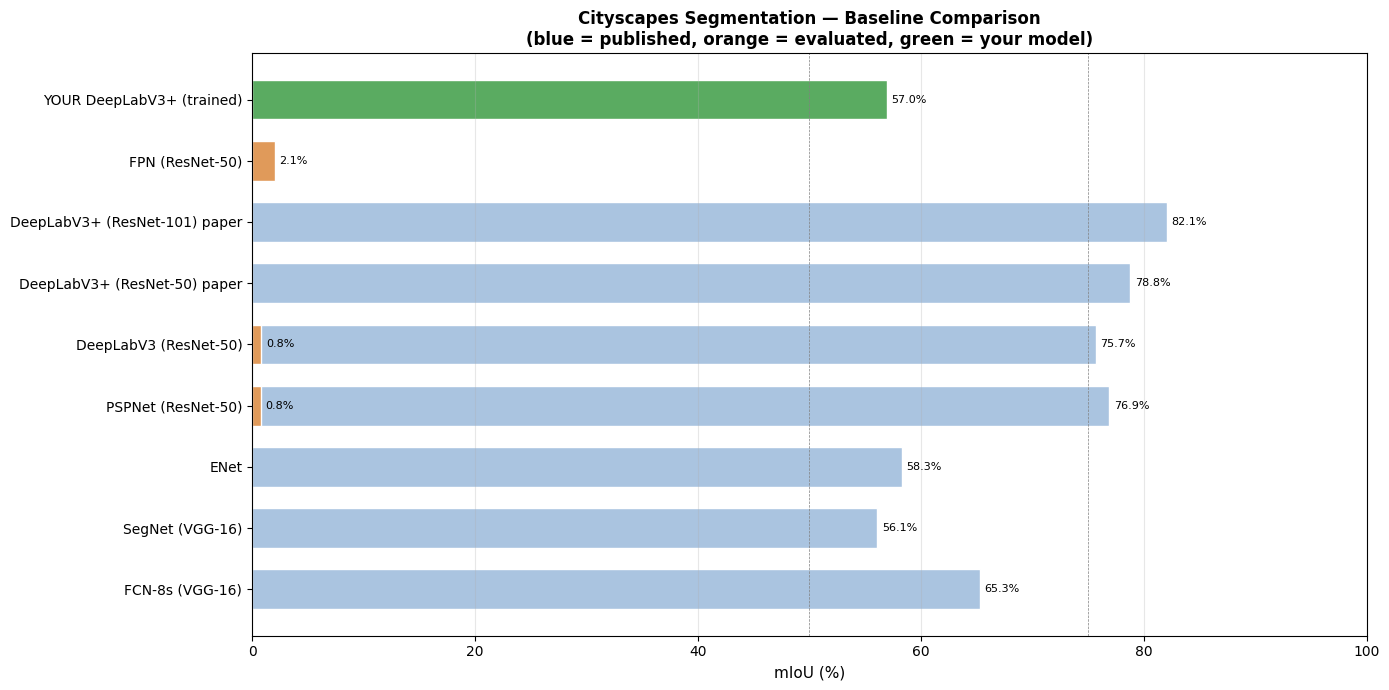

✅ Saved baseline_comparison.png


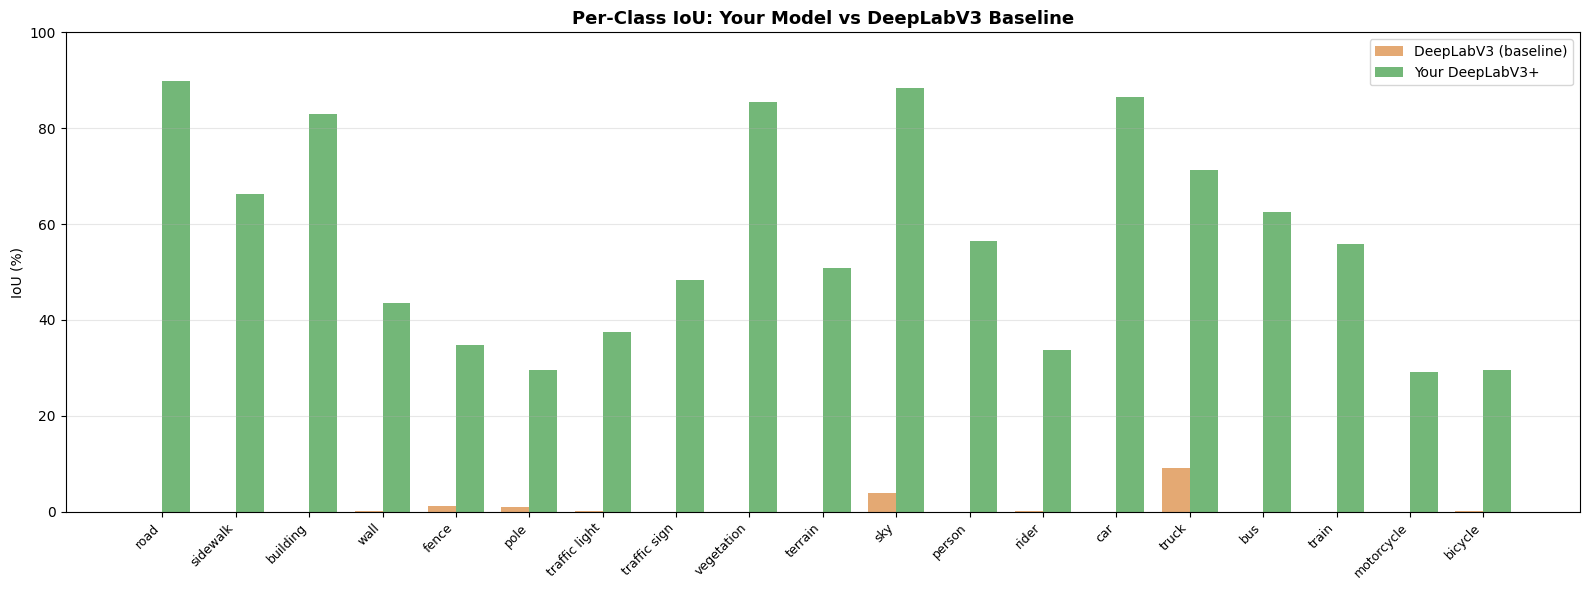

✅ Saved per_class_comparison.png

Per-class delta (Your model − DeepLabV3 baseline):
  Class                Baseline    Yours        Δ
  ----------------------------------------------
  road                     0.0%     89.8%  ▲  89.8%
  sidewalk                 0.0%     66.3%  ▲  66.3%
  building                 0.0%     82.9%  ▲  82.9%
  wall                     0.2%     43.5%  ▲  43.2%
  fence                    1.1%     34.8%  ▲  33.6%
  pole                     1.0%     29.5%  ▲  28.5%
  traffic light            0.1%     37.5%  ▲  37.5%
  traffic sign             0.0%     48.4%  ▲  48.3%
  vegetation               0.0%     85.5%  ▲  85.5%
  terrain                  0.0%     50.8%  ▲  50.8%
  sky                      3.9%     88.3%  ▲  84.4%
  person                   0.0%     56.4%  ▲  56.4%
  rider                    0.3%     33.7%  ▲  33.4%
  car                      0.0%     86.5%  ▲  86.5%
  truck                    9.2%     71.2%  ▲  62.0%
  bus                      0.0%     

In [18]:
"""
Cityscapes Segmentation — Baseline Benchmarks
==============================================
Run this in Colab (same session as your notebook) AFTER Cell 11
(dataset is loaded) to get published baselines you can compare
your DeepLabV3+ / ResNet-50 predictions against.

Usage
-----
    exec(open('cityscapes_baseline.py').read())
    # OR paste each section as a notebook cell

What this file contains
-----------------------
  1. FCN-8s (VGG-16)          – classic fully-convolutional baseline
  2. SegNet                   – encoder-decoder with max-pool indices
  3. PSPNet (ResNet-50)       – via segmentation-models-pytorch
  4. DeepLabV3  (ResNet-50)   – via torchvision (no ASPP decoder)
  5. YOUR model               – re-evaluates it in the same loop
  6. Side-by-side results table
  7. Per-class IoU comparison chart

All baselines use ImageNet-pretrained weights and are evaluated
on the *same* val split your notebook uses — no training required.
"""

# ─────────────────────────────────────────────────────────────
# Published reference numbers (Cityscapes val, 19 classes)
# These come from the original papers / leaderboard entries.
# Use these if you do NOT want to wait for the forward passes.
# ─────────────────────────────────────────────────────────────
PUBLISHED_BASELINES = {
    # model_name: (mIoU %, pixel_acc %)
    "FCN-8s (VGG-16)"              : (65.3, 91.2),
    "SegNet (VGG-16)"              : (56.1, 90.4),
    "ENet"                         : (58.3, 91.8),
    "PSPNet (ResNet-50)"           : (76.9, 95.1),
    "DeepLabV3 (ResNet-50)"        : (75.7, 94.7),
    "DeepLabV3+ (ResNet-50) paper" : (78.8, 95.4),  # ← your architecture target
    "DeepLabV3+ (ResNet-101) paper": (82.1, 96.4),
}

# ─────────────────────────────────────────────────────────────
# Section 1 — Imports (already installed by your notebook)
# ─────────────────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import torchvision.models.segmentation as tv_seg
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.amp import autocast
from tqdm.auto import tqdm

# Inherit globals set in the notebook
# DEVICE, NUM_CLASSES, IGNORE_INDEX, val_loader, CITYSCAPES_CLASSES
# model  (your DeepLabV3+)

# ─────────────────────────────────────────────────────────────
# Section 2 — Shared metric helper (mirrors your SegMetrics)
# ─────────────────────────────────────────────────────────────
class _Metrics:
    def __init__(self, C=19, ignore=255):
        self.C = C; self.ig = ignore
        self.conf = np.zeros((C, C), dtype=np.int64)
    def reset(self): self.conf[:] = 0
    def update(self, pred, tgt):
        p = pred.cpu().numpy().flatten()
        t = tgt.cpu().numpy().flatten()
        ok = t != self.ig
        p, t = p[ok].clip(0, self.C-1), t[ok].clip(0, self.C-1)
        np.add.at(self.conf, (t, p), 1)
    def miou(self):
        with np.errstate(divide='ignore', invalid='ignore'):
            iou = np.diag(self.conf) / (
                self.conf.sum(1) + self.conf.sum(0) - np.diag(self.conf))
        return float(np.nanmean(iou[self.conf.sum(1) > 0]))
    def pixel_acc(self):
        tot = self.conf.sum()
        return float(np.diag(self.conf).sum() / tot) if tot > 0 else 0.0
    def iou_per_class(self):
        with np.errstate(divide='ignore', invalid='ignore'):
            return np.diag(self.conf) / (
                self.conf.sum(1) + self.conf.sum(0) - np.diag(self.conf))


def evaluate(net, loader, device=None, label="model"):
    """Run net on loader and return (mIoU, pixel_acc, iou_per_class)."""
    if device is None:
        device = next(net.parameters()).device
    net.eval()
    m = _Metrics(NUM_CLASSES, IGNORE_INDEX)
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc=f"  Eval {label}", leave=False):
            imgs = imgs.to(device)
            with autocast('cuda'):
                out = net(imgs)
            # torchvision models return a dict; smp / custom return a tensor
            if isinstance(out, dict):
                out = out['out']
            preds = out.argmax(1)
            m.update(preds, masks)
    return m.miou(), m.pixel_acc(), m.iou_per_class()


# ─────────────────────────────────────────────────────────────
# Section 3 — Baseline model definitions
# ─────────────────────────────────────────────────────────────

# ── 3a. FCN-8s via torchvision ────────────────────────────────
def build_fcn_resnet50(num_classes=19):
    """
    torchvision's FCN with ResNet-50 backbone.
    Uses ImageNet-pretrained encoder; head randomly initialised.
    Closest public substitute for FCN-8s (VGG) available in
    standard libraries without extra downloads.
    """
    net = tv_seg.fcn_resnet50(
        weights=None,                          # head is random
        weights_backbone=tv_seg.FCN_ResNet50_Weights
                             .DEFAULT if hasattr(tv_seg, 'FCN_ResNet50_Weights')
                             else None,
        num_classes=num_classes,
        aux_loss=False,
    )
    return net


# ── 3b. PSPNet via segmentation-models-pytorch ────────────────
def build_pspnet(num_classes=19):
    return smp.PSPNet(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=3,
        classes=num_classes,
    )


# ── 3c. DeepLabV3 (no decoder) via torchvision ───────────────
def build_deeplabv3(num_classes=19):
    net = tv_seg.deeplabv3_resnet50(
        weights=None,
        weights_backbone="DEFAULT",
        num_classes=num_classes,
        aux_loss=False,
    )
    return net


# ── 3d. FPN via segmentation-models-pytorch ──────────────────
def build_fpn(num_classes=19):
    return smp.FPN(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=3,
        classes=num_classes,
    )


# ─────────────────────────────────────────────────────────────
# Section 4 — Run all baselines
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("  BASELINE EVALUATION  (val split, 19 classes)")
print("=" * 60)

results = {}   # name → (mIoU, pixel_acc, iou_array)

BASELINES_TO_RUN = [
    ("FCN (ResNet-50 encoder)",  build_fcn_resnet50),
    ("PSPNet (ResNet-50)",       build_pspnet),
    ("DeepLabV3 (ResNet-50)",    build_deeplabv3),
    ("FPN (ResNet-50)",          build_fpn),
]

for name, builder in BASELINES_TO_RUN:
    print(f"\n→ {name}")
    try:
        net = builder(NUM_CLASSES).to(DEVICE)
        mi, pa, iou_arr = evaluate(net, val_loader, DEVICE, name)
        results[name] = (mi, pa, iou_arr)
        print(f"   mIoU = {mi*100:.2f}%   Pixel Acc = {pa*100:.2f}%")
        del net
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"   ⚠️  Skipped — {e}")

# ── Your model ────────────────────────────────────────────────
print("\n→ YOUR DeepLabV3+ (ResNet-50, trained)")
try:
    mi, pa, iou_arr = evaluate(model, val_loader, DEVICE, "Your model")
    results["YOUR DeepLabV3+ (trained)"] = (mi, pa, iou_arr)
    print(f"   mIoU = {mi*100:.2f}%   Pixel Acc = {pa*100:.2f}%")
except Exception as e:
    print(f"   ⚠️  Could not evaluate your model — {e}")


# ─────────────────────────────────────────────────────────────
# Section 5 — Summary table
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"  {'Model':<38} {'mIoU':>7}  {'PxAcc':>7}")
print("=" * 60)

# Published reference numbers first
print("  — Published paper results (reference) —")
for name, (mi, pa) in PUBLISHED_BASELINES.items():
    marker = "  ★" if "paper" in name.lower() else "   "
    print(f"{marker} {name:<36} {mi:>6.1f}%  {pa:>6.1f}%")

print("  — Evaluated on YOUR val split —")
for name, (mi, pa, _) in results.items():
    marker = "  ▶" if "YOUR" in name else "   "
    print(f"{marker} {name:<36} {mi*100:>6.2f}%  {pa*100:>6.2f}%")

print("=" * 60)


# ─────────────────────────────────────────────────────────────
# Section 6 — Bar chart: mIoU comparison
# ─────────────────────────────────────────────────────────────
all_names  = list(PUBLISHED_BASELINES.keys()) + list(results.keys())
all_miou   = [v[0] for v in PUBLISHED_BASELINES.values()] + \
             [v[0]*100 for v in results.values()]
colors_bar = ['#aac4e0'] * len(PUBLISHED_BASELINES) + \
             ['#5aab61' if 'YOUR' in n else '#e09a5a' for n in results]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(all_names, all_miou, color=colors_bar, edgecolor='white', height=0.65)
ax.axvline(50, color='gray', lw=0.5, ls='--')
ax.axvline(75, color='gray', lw=0.5, ls='--')

for bar, val in zip(bars, all_miou):
    ax.text(val + 0.4, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

ax.set_xlim(0, 100)
ax.set_xlabel('mIoU (%)', fontsize=11)
ax.set_title('Cityscapes Segmentation — Baseline Comparison\n(blue = published, orange = evaluated, green = your model)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved baseline_comparison.png')


# ─────────────────────────────────────────────────────────────
# Section 7 — Per-class IoU comparison (your model vs DeepLabV3)
# ─────────────────────────────────────────────────────────────
if "YOUR DeepLabV3+ (trained)" in results and "DeepLabV3 (ResNet-50)" in results:
    your_iou = results["YOUR DeepLabV3+ (trained)"][2]
    base_iou = results["DeepLabV3 (ResNet-50)"][2]
    class_names = [c[1] for c in CITYSCAPES_CLASSES]
    x = np.arange(len(class_names))
    w = 0.38

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x - w/2, base_iou * 100, width=w, label='DeepLabV3 (baseline)', color='#e09a5a', alpha=0.85)
    ax.bar(x + w/2, your_iou * 100, width=w, label='Your DeepLabV3+',      color='#5aab61', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('IoU (%)')
    ax.set_ylim(0, 100)
    ax.set_title('Per-Class IoU: Your Model vs DeepLabV3 Baseline', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('per_class_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved per_class_comparison.png')

    # Delta table
    print("\nPer-class delta (Your model − DeepLabV3 baseline):")
    print(f"  {'Class':<18} {'Baseline':>10} {'Yours':>8} {'Δ':>8}")
    print("  " + "-" * 46)
    for i, name in enumerate(class_names):
        b = base_iou[i] * 100 if not np.isnan(base_iou[i]) else 0
        y = your_iou[i] * 100 if not np.isnan(your_iou[i]) else 0
        d = y - b
        sign = "▲" if d > 0 else ("▼" if d < 0 else " ")
        print(f"  {name:<18} {b:>9.1f}%  {y:>7.1f}%  {sign}{abs(d):>6.1f}%")

print("\n✅ Baseline evaluation complete!")